<a href="https://colab.research.google.com/github/lenhofda/ML-Final-Project/blob/main/Telecon_Customer_Churn_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [97]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [98]:
df = pd.read_csv("customer_churn_telecom_services.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [99]:
# Split the original dataset into 70% training and 30% testing
train_data, test_data = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["Churn"]
)

# Display the size of each dataset
print("Original dataset:", df.shape)
print("Training dataset (70%):", train_data.shape)
print("Testing dataset (30%):", test_data.shape)

Original dataset: (7043, 20)
Training dataset (70%): (4930, 20)
Testing dataset (30%): (2113, 20)


In [100]:
print("Training Churn Distribution:")
print(train_data["Churn"].value_counts(normalize=True))

print("\nTesting Churn Distribution:")
print(test_data["Churn"].value_counts(normalize=True))

Training Churn Distribution:
Churn
No     0.734686
Yes    0.265314
Name: proportion, dtype: float64

Testing Churn Distribution:
Churn
No     0.734501
Yes    0.265499
Name: proportion, dtype: float64


## Exploratory Data Analysis (Training Data Only) - Seth Alvarez

In [101]:
# Step 1: Structure of the training data
# This shows the number of rows and columns in the training set.
print("Training data shape:", train_data.shape)
print()

# This shows each column's name, data type, and non-null count.
train_data.info()

Training data shape: (4930, 20)

<class 'pandas.DataFrame'>
Index: 4930 entries, 5557 to 5639
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            4930 non-null   str    
 1   SeniorCitizen     4930 non-null   int64  
 2   Partner           4930 non-null   str    
 3   Dependents        4930 non-null   str    
 4   tenure            4930 non-null   int64  
 5   PhoneService      4930 non-null   str    
 6   MultipleLines     4930 non-null   str    
 7   InternetService   4930 non-null   str    
 8   OnlineSecurity    4930 non-null   str    
 9   OnlineBackup      4930 non-null   str    
 10  DeviceProtection  4930 non-null   str    
 11  TechSupport       4930 non-null   str    
 12  StreamingTV       4930 non-null   str    
 13  StreamingMovies   4930 non-null   str    
 14  Contract          4930 non-null   str    
 15  PaperlessBilling  4930 non-null   str    
 16  PaymentMethod     4930

In [102]:
# Step 2: Summary statistics for numeric features
# SeniorCitizen is only 0 or 1, so we treat it as a category.
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

# This shows the count, mean, standard deviation, minimum, quartiles, and maximum.
print("Summary statistics (numeric features):")
print(train_data[numeric_features].describe().round(2))

Summary statistics (numeric features):
        tenure  MonthlyCharges  TotalCharges
count  4930.00         4930.00       4923.00
mean     32.47           64.95       2305.07
std      24.65           30.24       2292.55
min       0.00           18.40         18.85
25%       9.00           35.50        399.80
50%      29.00           70.57       1389.20
75%      56.00           90.05       3860.30
max      72.00          118.75       8684.80


In [103]:
# Step 3: Summary statistics for categorical features
# This selects all columns that are not numeric and are not the target (Churn).
categorical_features = [col for col in train_data.columns
                        if col not in numeric_features + ["Churn"]]

# This counts each category in each column.
for col in categorical_features:
    print(f"--- {col} ---")
    print(train_data[col].value_counts())
    print()

--- gender ---
gender
Male      2478
Female    2452
Name: count, dtype: int64

--- SeniorCitizen ---
SeniorCitizen
0    4136
1     794
Name: count, dtype: int64

--- Partner ---
Partner
No     2558
Yes    2372
Name: count, dtype: int64

--- Dependents ---
Dependents
No     3463
Yes    1467
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    4434
No      496
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  2347
Yes                 2087
No phone service     496
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    2177
DSL            1685
No             1068
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No                     2439
Yes                    1423
No internet service    1068
Name: count, dtype: int64

--- OnlineBackup ---
OnlineBackup
No                     2142
Yes                    1720
No internet service    1068
Name: count, dtype: int64

--- DeviceProtection ---
DeviceProtect

Churn counts:
Churn
No     3622
Yes    1308
Name: count, dtype: int64

Churn percentages:
Churn
No     73.47
Yes    26.53
Name: proportion, dtype: float64


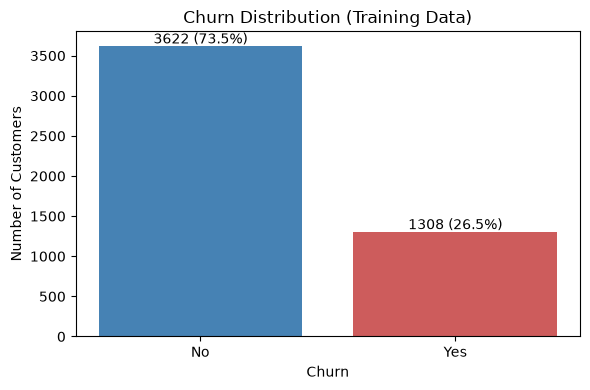

In [104]:
# Step 4: Target variable distribution (Churn)
# This counts the customers in each class as numbers and percentages.
churn_counts = train_data["Churn"].value_counts()
churn_pct = train_data["Churn"].value_counts(normalize=True) * 100

print("Churn counts:")
print(churn_counts)
print("\nChurn percentages:")
print(churn_pct.round(2))

# This shows a bar chart of the two classes, which is also the "before" chart for class balancing.
plt.figure(figsize=(6, 4))
plt.bar(churn_counts.index, churn_counts.values, color=["steelblue", "indianred"])
plt.title("Churn Distribution (Training Data)")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 30, f"{v} ({churn_pct.values[i]:.1f}%)", ha="center")
plt.tight_layout()
plt.show()

Skewness (0 = balanced, > 0 = right-skewed, < 0 = left-skewed):
tenure            0.24
MonthlyCharges   -0.22
TotalCharges      0.95
dtype: float64


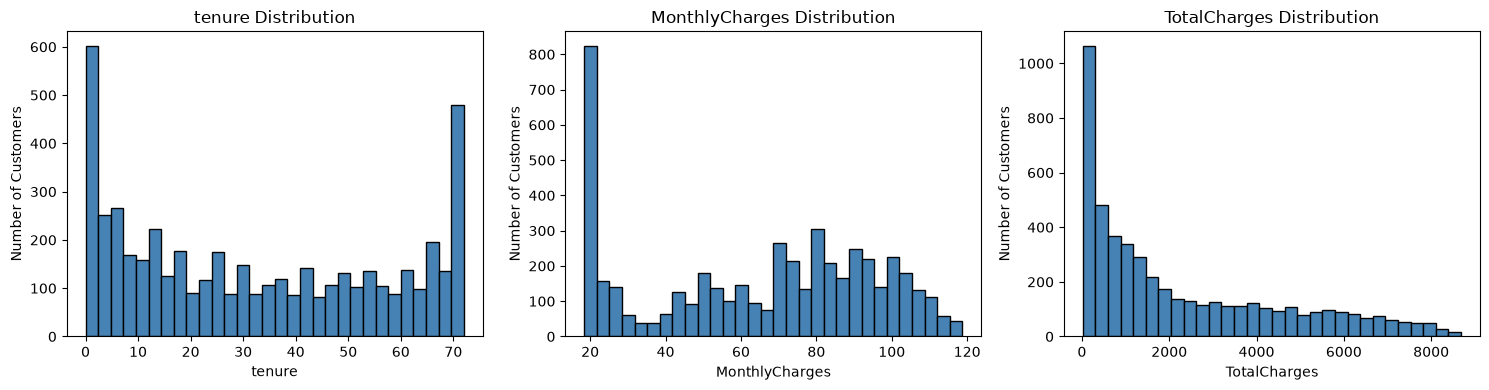

In [105]:
# Step 5: Distributions of numeric features
# This shows the skewness of each column. Near 0 means balanced, above 0 means right-skewed.
print("Skewness (0 = balanced, > 0 = right-skewed, < 0 = left-skewed):")
print(train_data[numeric_features].skew().round(2))

# This shows a histogram for each numeric column. dropna() skips the 7 missing TotalCharges values.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_features):
    axes[i].hist(train_data[col].dropna(), bins=30, color="steelblue", edgecolor="black")
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Median values by Churn:
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       38.0           64.45       1679.40
Yes      10.0           80.00        705.08


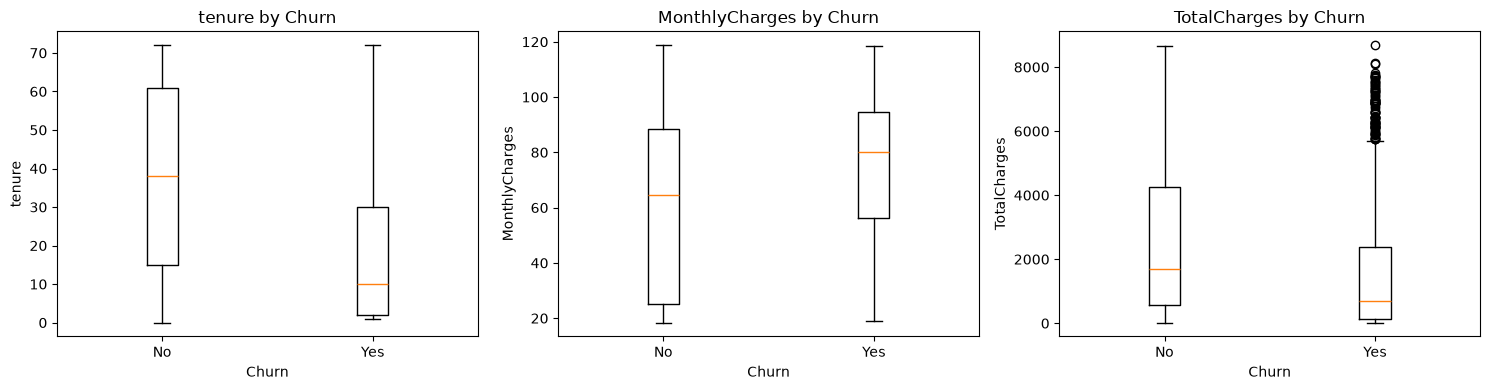

In [106]:
# Step 6: Numeric features compared by Churn
# This shows the median of each numeric column for customers who stayed and who left.
print("Median values by Churn:")
print(train_data.groupby("Churn")[numeric_features].median().round(2))

# This shows a box plot of each numeric column, split by Churn.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_features):
    data_no = train_data.loc[train_data["Churn"] == "No", col].dropna()
    data_yes = train_data.loc[train_data["Churn"] == "Yes", col].dropna()
    axes[i].boxplot([data_no, data_yes], tick_labels=["No", "Yes"])
    axes[i].set_title(f"{col} by Churn")
    axes[i].set_xlabel("Churn")
    axes[i].set_ylabel(col)
plt.tight_layout()
plt.show()

--- Churn rate (%) by gender ---
gender
Female    26.3
Male      26.8

--- Churn rate (%) by SeniorCitizen ---
SeniorCitizen
0    23.7
1    41.1

--- Churn rate (%) by Partner ---
Partner
No     32.9
Yes    19.6

--- Churn rate (%) by Dependents ---
Dependents
No     31.5
Yes    14.9

--- Churn rate (%) by PhoneService ---
PhoneService
No     23.4
Yes    26.9

--- Churn rate (%) by MultipleLines ---
MultipleLines
No                  25.1
No phone service    23.4
Yes                 28.9

--- Churn rate (%) by InternetService ---
InternetService
DSL            19.2
Fiber optic    41.8
No              6.9

--- Churn rate (%) by OnlineSecurity ---
OnlineSecurity
No                     42.0
No internet service     6.9
Yes                    14.7

--- Churn rate (%) by OnlineBackup ---
OnlineBackup
No                     40.3
No internet service     6.9
Yes                    21.6

--- Churn rate (%) by DeviceProtection ---
DeviceProtection
No                     39.2
No internet service   

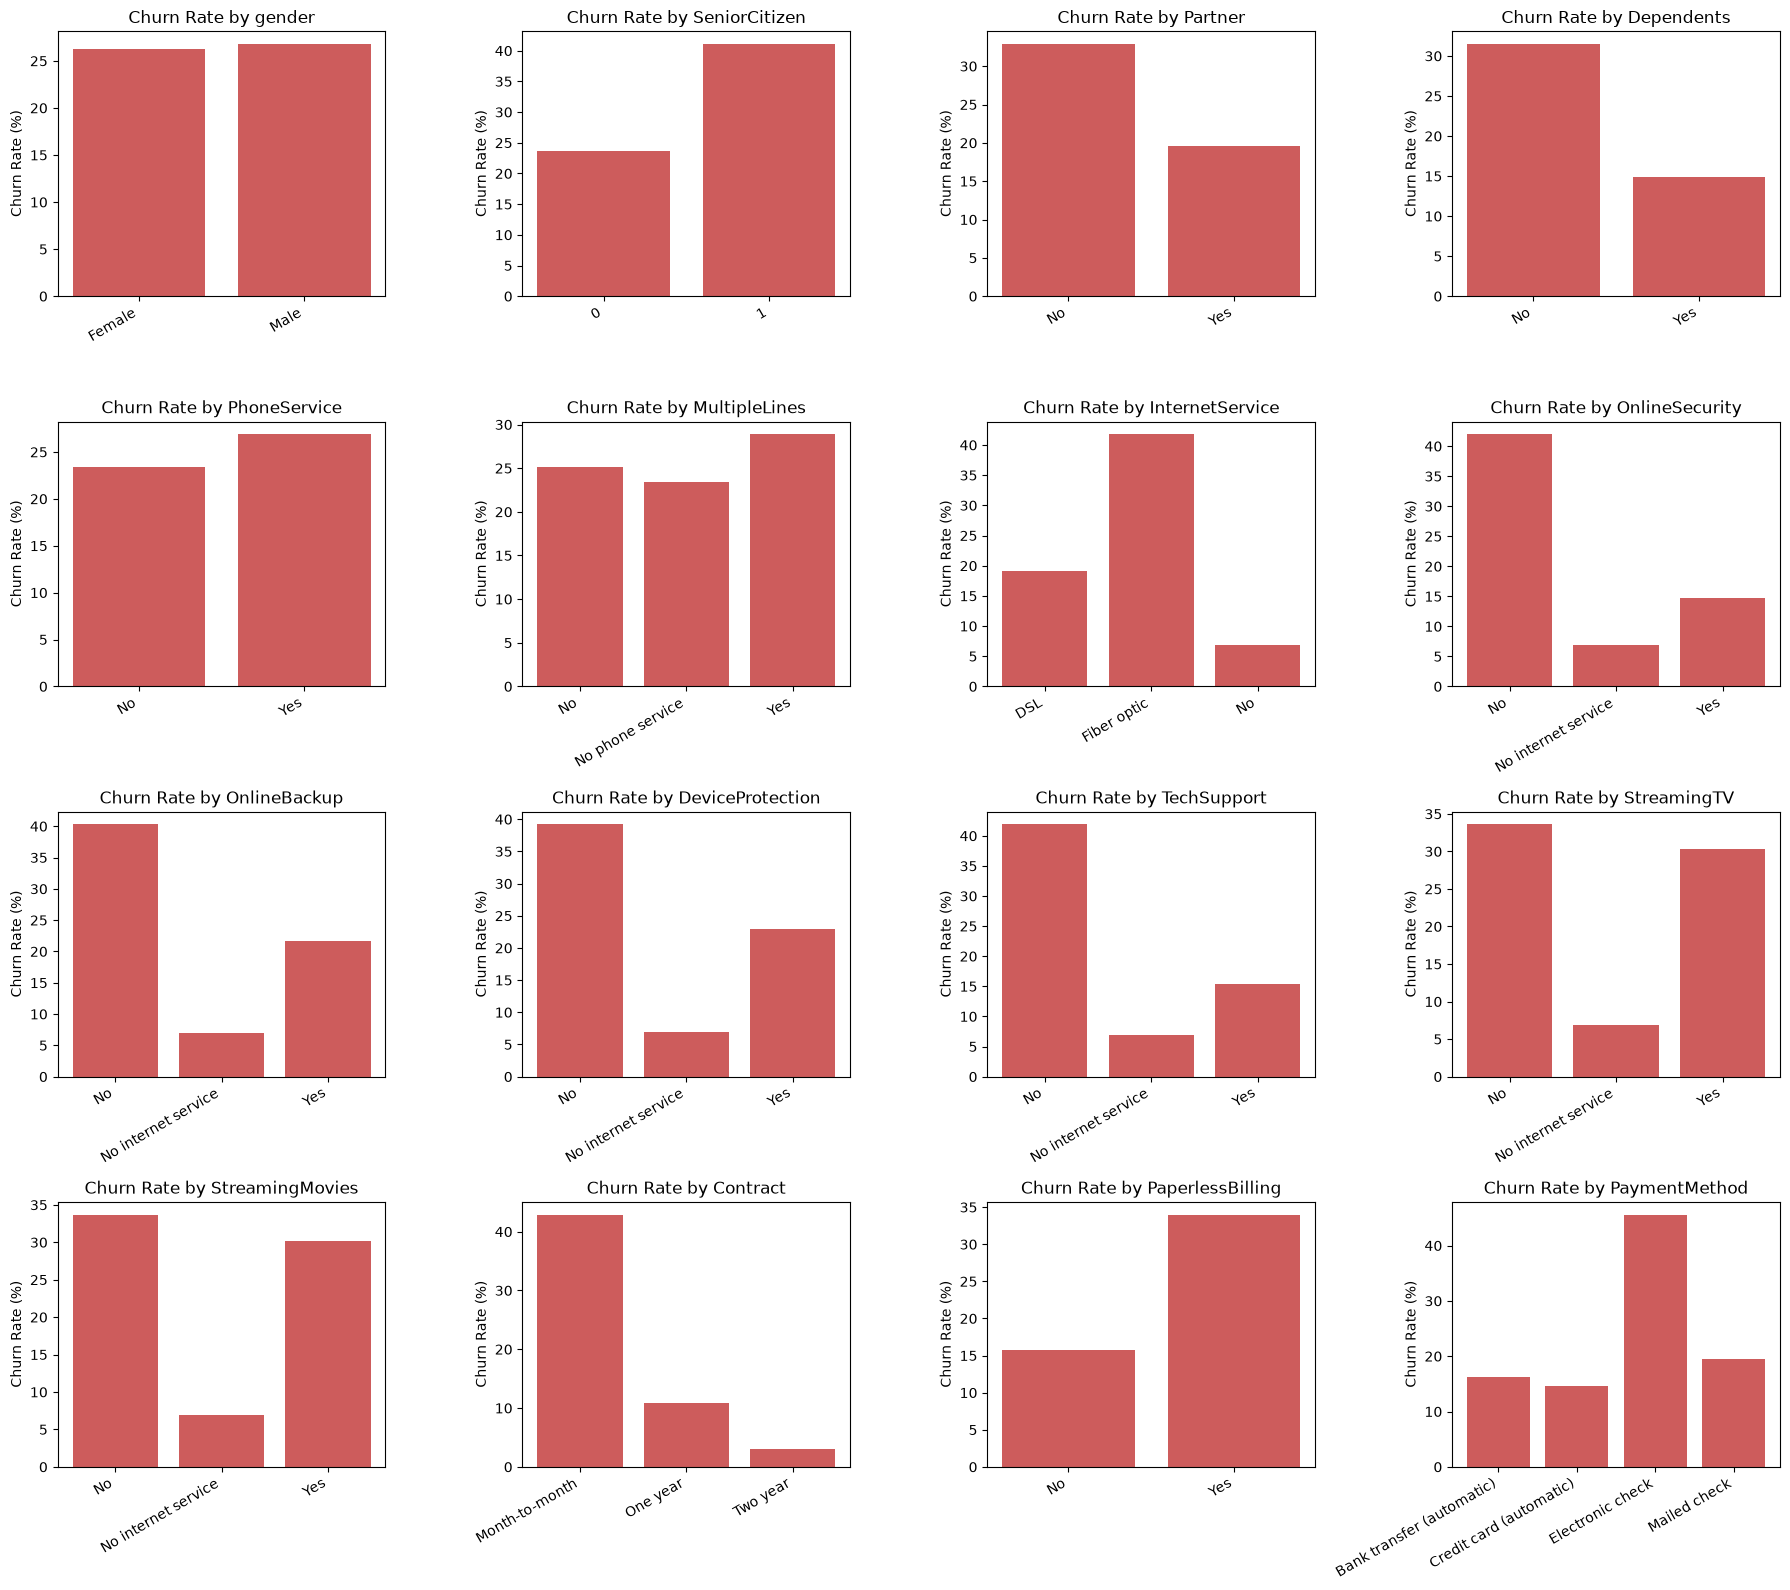

In [107]:
# Step 7: Churn rate for each categorical feature
# This shows the percent of customers who left in each category, as text and as a 4 x 4 chart grid.
churn_flag = train_data["Churn"] == "Yes"
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
for ax, col in zip(axes.flatten(), categorical_features):
    rates = (churn_flag.groupby(train_data[col]).mean() * 100).round(1)
    print(f"--- Churn rate (%) by {col} ---\n{rates.to_string()}\n")
    ax.bar(rates.index.astype(str), rates.values, color="indianred")
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate (%)")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

Correlation matrix:
                tenure  MonthlyCharges  TotalCharges
tenure            1.00            0.26          0.83
MonthlyCharges    0.26            1.00          0.65
TotalCharges      0.83            0.65          1.00


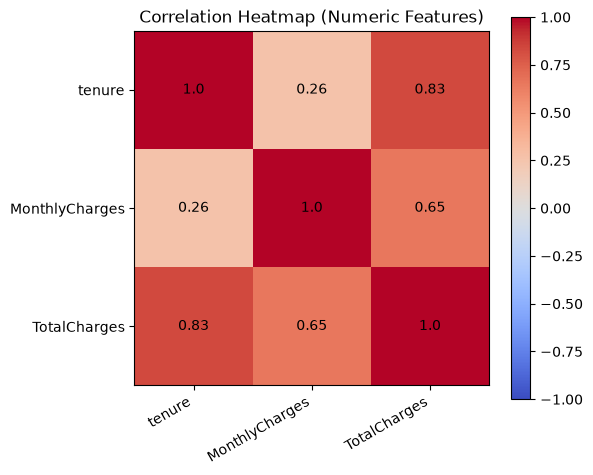

In [108]:
# Step 8: Correlation between numeric features
# This shows how strongly each pair of numeric columns moves together, from -1 to 1.
corr = train_data[numeric_features].corr().round(2)
print("Correlation matrix:")
print(corr)

# This shows the matrix as a heatmap with each value written in its cell.
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_features)), numeric_features, rotation=30, ha="right")
ax.set_yticks(range(len(numeric_features)), numeric_features)
for i in range(len(numeric_features)):
    for j in range(len(numeric_features)):
        ax.text(j, i, corr.iloc[i, j], ha="center", va="center")
fig.colorbar(im)
ax.set_title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

In [109]:
# Step 9: Missing values and duplicates (found here, fixed in the cleaning section)
# This shows each column with missing values and the rows where TotalCharges is missing.
missing = train_data.isnull().sum()
print("Columns with missing values:")
print(missing[missing > 0])
print("\nRows with missing TotalCharges:")
print(train_data.loc[train_data["TotalCharges"].isnull(), ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

# This is the number of fully duplicated rows in the training set.
print("\nDuplicate rows:", train_data.duplicated().sum())

Columns with missing values:
TotalCharges    7
dtype: int64

Rows with missing TotalCharges:
      tenure  MonthlyCharges  TotalCharges Churn
6670       0           73.35           NaN    No
3826       0           25.35           NaN    No
4380       0           20.00           NaN    No
488        0           52.55           NaN    No
1082       0           25.75           NaN    No
6754       0           61.90           NaN    No
3331       0           19.85           NaN    No

Duplicate rows: 9


### EDA Summary and Preprocessing Plan

**Data quality**
- TotalCharges has 7 missing values, and all 7 rows have tenure = 0. These customers have no bill yet, so their TotalCharges should be 0.
- The training set has 9 duplicate rows and the data has no customer ID, so these could be different customers who happen to have the same values.
- The category labels are clean, with no spelling mistakes.

**Distributions**
- Most TotalCharges values are low and only a few are very high (skewness 0.95), so a log transform should even it out.
- The two biggest groups of customers are brand new ones and ones who have stayed about 72 months. MonthlyCharges has a big group near 20, which is customers with no internet.
- tenure only goes up to 72, but TotalCharges goes up to 8,685. These columns need scaling so that TotalCharges doesn't count more than tenure just because its numbers are bigger.

**Target**
- 73.5% of customers stayed and 26.5% left. The classes need balancing, but only on the training set.

**Churn patterns**
- Customers leave the most when they are on month-to-month contracts (42.9%), pay by electronic check (45.6%), have fiber optic (41.8%), or have no OnlineSecurity or TechSupport (about 42%).
- Customers who left stayed a shorter time (median 10 months compared to 38) and paid more each month (median 80 compared to 64).
- Men and women leave at about the same rate.
- tenure and TotalCharges go up together (correlation 0.83). This is under the 0.9 limit, so both columns stay.

**Encoding plan**
- Yes/No columns become 1 and 0.
- Contract goes from shortest to longest (Month-to-month, One year, Two year), so it gets label encoding.
- InternetService, PaymentMethod, MultipleLines and the internet add-on columns have no order, so they get one-hot encoding.
- SeniorCitizen is already 0 and 1, so it stays as is.

**Feature engineering ideas**
- Count how many protection and support services each customer has (OnlineSecurity, OnlineBackup, DeviceProtection and TechSupport).
- Group tenure into 0-12, 13-24, 25-48 and 49-72 months to show churn by how long someone has been a customer.

## Categorical Encoding + One-Hot Encoding + Feature Engineering - Aaliyah Phillips

In [110]:
import pandas as pd
import matplotlib.pyplot as plt

# Missing Values
# Identified in Seth's EDA, missing TotalCharges correspond to tenure=0
train_clean = train_data.copy() # copy to work on
train_clean['TotalCharges'] = pd.to_numeric(train_clean['TotalCharges'], errors='coerce').fillna(0)

# Display categorical columns
print("Categorical Columns: Before")
cat_cols_before = train_clean.select_dtypes(exclude='number').columns.tolist()
print(cat_cols_before)

print("\nSample Data Before Encoding & Engineering:")
print(train_clean[['gender', 'Partner', 'Contract', 'InternetService', 'PaymentMethod']].head())

Categorical Columns: Before
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Sample Data Before Encoding & Engineering:
      gender Partner        Contract InternetService  \
5557  Female      No  Month-to-month     Fiber optic   
2270  Female      No  Month-to-month     Fiber optic   
6930  Female     Yes  Month-to-month     Fiber optic   
2257  Female      No        One year             DSL   
898   Female      No  Month-to-month     Fiber optic   

                  PaymentMethod  
5557           Electronic check  
2270           Electronic check  
6930    Credit card (automatic)  
2257    Credit card (automatic)  
898   Bank transfer (automatic)  


In [111]:
# Step 1: Feature Engineering
# Feature 1: Charges per Month of Tenure
print("\nEngineering Features")

# Feature 1: Charges per Month of Tenure
train_clean['ChargesPerMonth'] = train_clean['TotalCharges'] / (train_clean['tenure'] + 1)

# Feature 2: Tenure Cohort / Lifecycle Group
# Grouping tenure: 0-12m (new), 13-24m (settled), 25-48m (established), 49-72m (loyal)
tenure_bins = [-1, 12, 24, 48, 72]
tenure_labels = ['0-12m', '13-24m', '25-48m', '49-72m']
train_clean['TenureGroup'] = pd.cut(train_clean['tenure'], bins=tenure_bins, labels=tenure_labels)

# Feature 3: Long-Term Customer Indicator (tenure >= 24 months)
train_clean['LongTermCustomer'] = (train_clean['tenure'] >= 24).astype(int)

# Feature 4: Protection & Support Service Count
support_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
train_clean['SupportServiceCount'] = train_clean[support_services].apply(
    lambda row: (row == 'Yes').sum(), axis=1
)

print("Sample of Engineered Features:")
print(train_clean[['tenure', 'TenureGroup', 'LongTermCustomer', 'ChargesPerMonth', 'SupportServiceCount']].head())



Engineering Features
Sample of Engineered Features:
      tenure TenureGroup  LongTermCustomer  ChargesPerMonth  \
5557       5       0-12m                 0        64.041667   
2270       3       0-12m                 0        55.237500   
6930       3       0-12m                 0        54.187500   
2257      60      49-72m                 1        79.459836   
898       12       0-12m                 0        86.226923   

      SupportServiceCount  
5557                    0  
2270                    1  
6930                    0  
2257                    2  
898                     2  


In [112]:
# Step 2: Categorical Encoding (Binary & Ordinal)
print("\n--- Applying Categorical & Ordinal Encoding ---")

# 1. Target Variable (Churn)
if 'Churn' in train_clean.columns:
    train_clean['Churn'] = train_clean['Churn'].astype(str).str.strip().map({'Yes': 1, 'No': 0})

# 2. Binary Features (Yes / No)
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if col in train_clean.columns:
        train_clean[col] = train_clean[col].astype(str).str.strip().map({'Yes': 1, 'No': 0})

# 3. Gender (Female: 0, Male: 1)
if 'gender' in train_clean.columns:
    train_clean['gender'] = train_clean['gender'].astype(str).str.strip().map({'Female': 0, 'Male': 1})

# 4. Ordinal Encoding: Contract
if 'Contract' in train_clean.columns:
    contract_mapping = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
    train_clean['Contract_Ordinal'] = train_clean['Contract'].astype(str).str.strip().map(contract_mapping)
    contract_before_plot = train_clean['Contract'].copy()
    train_clean = train_clean.drop(columns=['Contract'])
else:
    contract_before_plot = None

# 5. Drop customerID if present
if 'customerID' in train_clean.columns:
    train_clean = train_clean.drop(columns=['customerID'])


--- Applying Categorical & Ordinal Encoding ---


In [113]:
# Step 3: One-Hot Encoding
print("\n Applying One-Hot Encoding ")

nominal_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport','StreamingTV',
    'StreamingMovies', 'PaymentMethod', 'TenureGroup'
]
# Only encode nominal columns that exist in DataFrame
nominal_cols = [col for col in nominal_cols if col in train_clean.columns]

train_processed = pd.get_dummies(train_clean, columns=nominal_cols, drop_first=True, dtype=int)

print(f"Shape Before: {train_data.shape}")
print(f"Shape After:  {train_processed.shape}")


 Applying One-Hot Encoding 
Shape Before: (4930, 20)
Shape After:  (4930, 36)


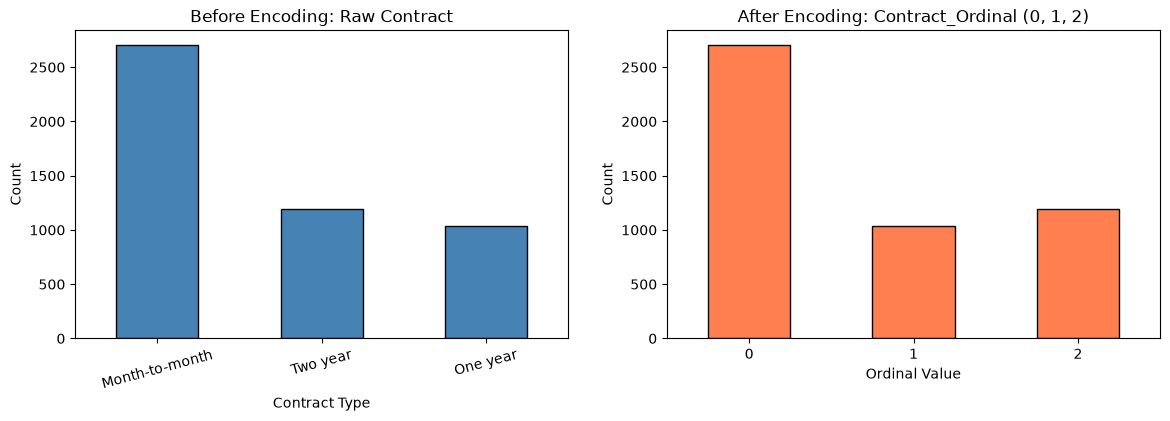

In [114]:
# Step 4: Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Visualization 1: Before & After Contract Encoding
if contract_before_plot is not None and 'Contract_Ordinal' in train_processed.columns:
    contract_before_plot.value_counts().plot(
        kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
    )
    axes[0].set_title("Before Encoding: Raw Contract")
    axes[0].set_xlabel("Contract Type")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis='x', rotation=15)

    train_processed['Contract_Ordinal'].value_counts().sort_index().plot(
        kind='bar', ax=axes[1], color='coral', edgecolor='black'
    )
    axes[1].set_title("After Encoding: Contract_Ordinal (0, 1, 2)")
    axes[1].set_xlabel("Ordinal Value")
    axes[1].set_ylabel("Count")
    axes[1].tick_params(axis='x', rotation=0)

plt.show()

In [118]:
# To verify all columns are strictly numeric (no objects or strings)
print("Non-numeric columns remaining:", non_numeric)

Non-numeric columns remaining: []


## Notes 
* Be sure to start with "train_processed" instead of "train_data" or "train_clean".
* You may need to add new numeric feature 'ChargesPerMonth' to numeric_cols if (StandardScaler) is needed:
  **numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ChargesPerMonth']**

## Feature Scaling & Normalization — Elquin Ponce


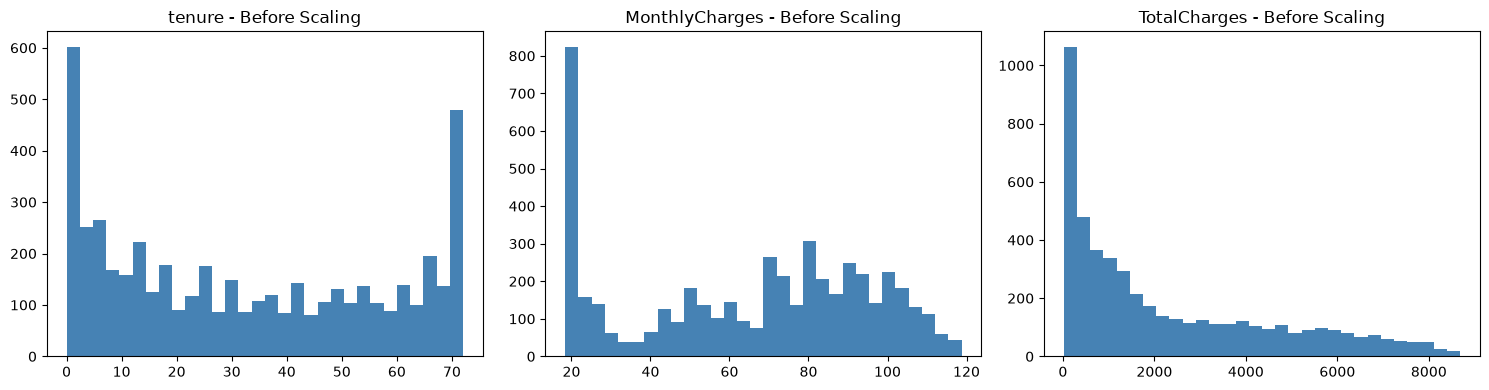

Sample after scaling:
        tenure  MonthlyCharges  TotalCharges
5557 -1.114728        0.504286     -0.837938
2270 -1.195884        0.724189     -0.909176
6930 -1.195884        0.337292     -0.911008
2257  1.117066        0.515860      1.108912
898  -0.830682        1.122660     -0.516560

Sample after normalization:
        tenure  MonthlyCharges  TotalCharges
5557  0.069444        0.615845      0.042165
2270  0.041667        0.682113      0.023321
6930  0.041667        0.565521      0.022837
2257  0.833333        0.619332      0.557146
898   0.166667        0.802192      0.127176


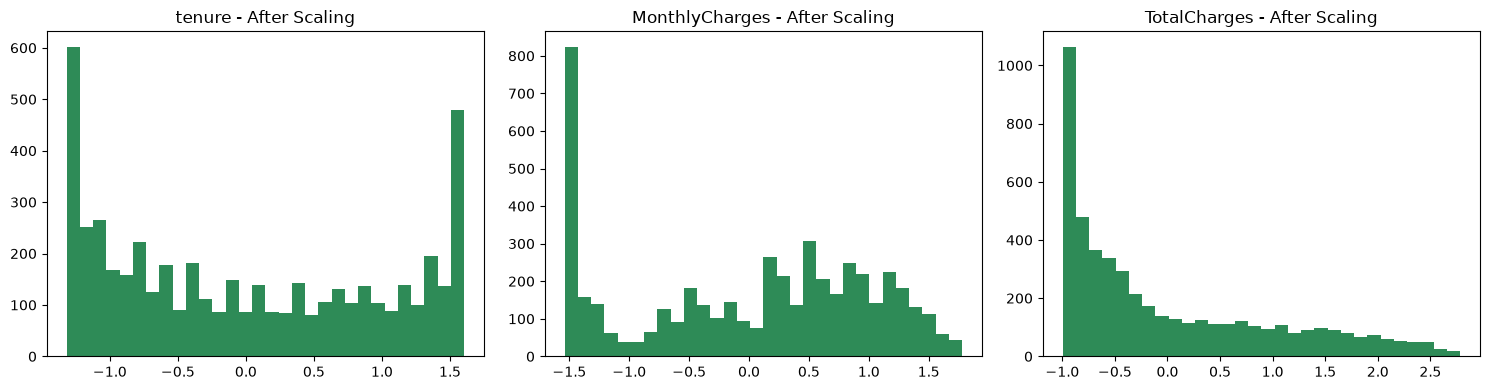

In [116]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# BEFORE: distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    axes[i].hist(train_data[col], bins=30, color='steelblue')
    axes[i].set_title(f'{col} - Before Scaling')
plt.tight_layout()
plt.show()

# SCALING (Standardization)
scaler = StandardScaler()
train_data[numeric_cols] = scaler.fit_transform(train_data[numeric_cols])
print("Sample after scaling:")
print(train_data[numeric_cols].head())

# NORMALIZATION (Min-Max)
minmax = MinMaxScaler()
train_data_normalized = train_data.copy()
train_data_normalized[numeric_cols] = minmax.fit_transform(train_data[numeric_cols])
print("\nSample after normalization:")
print(train_data_normalized[numeric_cols].head())

# AFTER: distribution plots post-scaling
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    axes[i].hist(train_data[col], bins=30, color='seagreen')
    axes[i].set_title(f'{col} - After Scaling')
plt.tight_layout()
plt.show()
